In [1]:
# Importing necessary libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Importing the dataset

books = pd.read_csv('Data_set/books.csv')

In [3]:
books

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6805,9788185300535,8185300534,I Am that,Talks with Sri Nisargadatta Maharaj,Sri Nisargadatta Maharaj;Sudhakar S. Dikshit,Philosophy,http://books.google.com/books/content?id=Fv_JP...,This collection of the timeless teachings of o...,1999.0,4.51,531.0,104.0
6806,9788185944609,8185944601,Secrets Of The Heart,NaN,Khalil Gibran,Mysticism,http://books.google.com/books/content?id=XcrVp...,NaN,1993.0,4.08,74.0,324.0
6807,9788445074879,8445074873,Fahrenheit 451,NaN,Ray Bradbury,Book burning,NaN,NaN,2004.0,3.98,186.0,5733.0
6808,9789027712059,9027712050,The Berlin Phenomenology,NaN,Georg Wilhelm Friedrich Hegel,History,http://books.google.com/books/content?id=Vy7Sk...,Since the three volume edition ofHegel's Philo...,1981.0,0.00,210.0,0.0


In [4]:
# Checking the structure of the dataset

books.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6810 entries, 0 to 6809
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   isbn13          6810 non-null   int64  
 1   isbn10          6810 non-null   object 
 2   title           6810 non-null   object 
 3   subtitle        2381 non-null   object 
 4   authors         6738 non-null   object 
 5   categories      6711 non-null   object 
 6   thumbnail       6481 non-null   object 
 7   description     6548 non-null   object 
 8   published_year  6804 non-null   float64
 9   average_rating  6767 non-null   float64
 10  num_pages       6767 non-null   float64
 11  ratings_count   6767 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 638.6+ KB


In [5]:
# Checking for duplicate values

print(sum(books.duplicated()))

0


In [6]:
books.drop(['isbn10'], axis=1, inplace=True)

In [7]:
# Checking for missing values

books.isnull().sum()

isbn13               0
title                0
subtitle          4429
authors             72
categories          99
thumbnail          329
description        262
published_year       6
average_rating      43
num_pages           43
ratings_count       43
dtype: int64

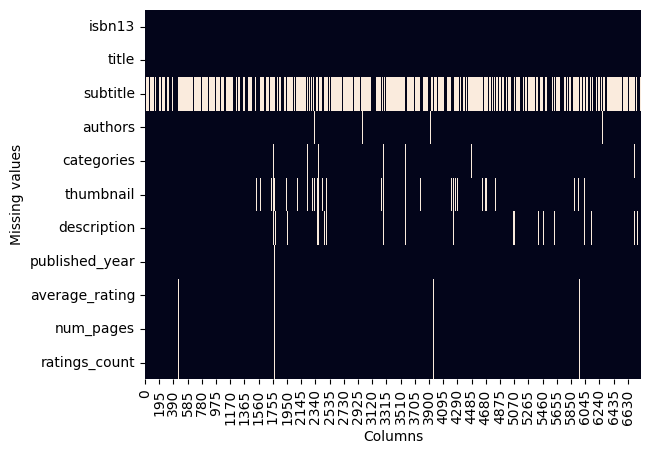

In [8]:
# Visualizing the missing values

ax = plt.axes()
sns.heatmap(books.isna().transpose(), cbar=False, ax = ax)
plt.xlabel('Columns')
plt.ylabel('Missing values')
plt.show()

In [9]:
# Feature Engineering

books['missing_description'] = books['description'].isnull().astype(int)
books['age_of_book'] = 2024 - books['published_year']

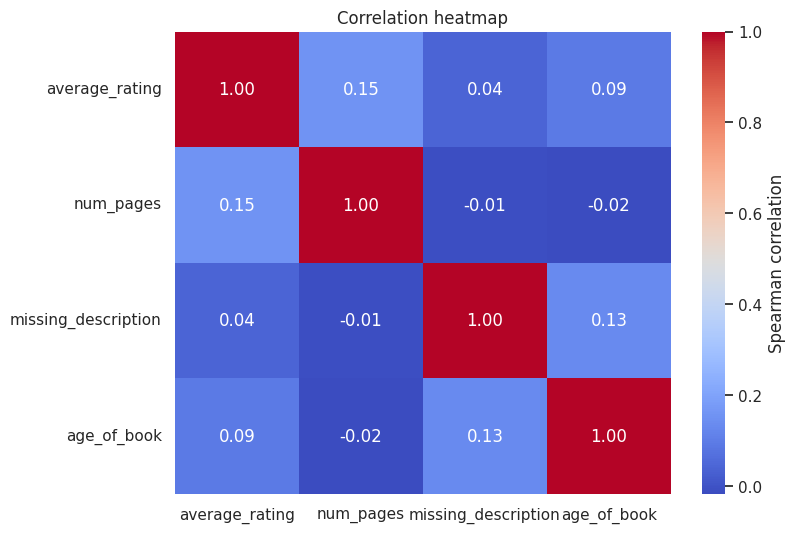

In [10]:
# Correlation heatmap for the variables that has missing data

columns_of_interest = ['average_rating', 'num_pages', 'missing_description', 'age_of_book']
corrleation_matrix = books[columns_of_interest].corr(method='spearman')
sns.set_theme(style='white')
plt.figure(figsize=(8,6))
heatmap = sns.heatmap(corrleation_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar_kws={'label': 'Spearman correlation'})
heatmap.set_title('Correlation heatmap')
plt.show()

In [11]:
# Displaying rows with missing values in key columns

books[books[['description', 'average_rating', 'num_pages', 'published_year']].isna().any(axis=1)]

,isbn13,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,missing_description,age_of_book
37,9780006906018,The Princess of the Chalet School,NaN,Elinor Mary Brent-Dyer,Juvenile Fiction,http://books.google.com/books/content?id=EJcQP...,NaN,2000.0,4.10,159.0,446.0,1,24.0
60,9780007127740,The illustrated man,NaN,Ray Bradbury,Fiction,http://books.google.com/books/content?id=kePql...,NaN,2002.0,4.14,186.0,56781.0,1,22.0
99,9780020442806,"The Chronicles of Narnia: Lion, the witch and ...",NaN,Clive Staples Lewis,Fairy tales,NaN,NaN,1978.0,4.26,1425.0,1446.0,1,46.0
102,9780023513206,Reason in History,A General Introduction to the Philosophy of Hi...,Georg Wilhelm Friedrich Hegel,Philosophy,http://books.google.com/books/content?id=BCvcY...,NaN,1953.0,3.64,95.0,430.0,1,71.0
105,9780026995016,Spandau,The Secret Diaries,Albert Speer,History,NaN,NaN,1976.0,4.12,463.0,6.0,1,48.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6787,9783464371640,About a Boy,NaN,Nick Hornby,NaN,http://books.google.com/books/content?id=PuDYw...,NaN,2002.0,3.80,256.0,155.0,1,22.0
6788,9783540292128,Enzyme-Catalyzed Synthesis of Polymers,NaN,Shiro Kobayashi;Helmut Ritter;David Kaplan,Science,http://books.google.com/books/content?id=WXOym...,NaN,2006.0,0.00,254.0,0.0,1,18.0
6798,9787506435673,Good Fight,NaN,Judd Winick;Matthew Clark,Juvenile Fiction,http://books.google.com/books/content?id=xGPZA...,Presents the adventures of a new group of hero...,2007.0,NaN,NaN,NaN,0,17.0
6806,9788185944609,Secrets Of The Heart,NaN,Khalil Gibran,Mysticism,http://books.google.com/books/content?id=XcrVp...,NaN,1993.0,4.08,74.0,324.0,1,31.0


In [12]:
# Dropping rows with missing values in key columns

books_missing = books[books[['description', 'average_rating', 'num_pages', 'published_year']].notna().all(axis=1)].copy()

In [13]:
books_missing

,isbn13,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,missing_description,age_of_book
0,9780002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0,0,20.0
1,9780002261982,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0,0,24.0
2,9780006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0,0,42.0
3,9780006178736,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0,0,31.0
4,9780006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0,0,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6803,9788173031014,Journey to the East,NaN,Hermann Hesse,Adventure stories,http://books.google.com/books/content?id=rq6JP...,This book tells the tale of a man who goes on ...,2002.0,3.70,175.0,24.0,0,22.0
6804,9788179921623,The Monk Who Sold His Ferrari: A Fable About F...,NaN,Robin Sharma,Health & Fitness,http://books.google.com/books/content?id=c_7mf...,"Wisdom to Create a Life of Passion, Purpose, a...",2003.0,3.82,198.0,1568.0,0,21.0
6805,9788185300535,I Am that,Talks with Sri Nisargadatta Maharaj,Sri Nisargadatta Maharaj;Sudhakar S. Dikshit,Philosophy,http://books.google.com/books/content?id=Fv_JP...,This collection of the timeless teachings of o...,1999.0,4.51,531.0,104.0,0,25.0
6808,9789027712059,The Berlin Phenomenology,NaN,Georg Wilhelm Friedrich Hegel,History,http://books.google.com/books/content?id=Vy7Sk...,Since the three volume edition ofHegel's Philo...,1981.0,0.00,210.0,0.0,0,43.0


In [14]:
# Adding a new feature: word count in the description

books_missing['words_in_description'] = books_missing['description'].str.split().str.len()

In [15]:
# Filtering out books with very short descriptions (less than 25 words)

books_missing_25 = books_missing[books_missing['words_in_description'] >= 25].copy()

In [16]:
books_missing_25

,isbn13,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,missing_description,age_of_book,words_in_description
0,9780002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0,0,20.0,199
1,9780002261982,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0,0,24.0,205
3,9780006178736,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0,0,31.0,57
4,9780006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0,0,22.0,45
5,9780006280934,The Problem of Pain,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=Kk-uV...,"""In The Problem of Pain, C.S. Lewis, one of th...",2002.0,4.09,176.0,37569.0,0,22.0,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6802,9788172235222,Mistaken Identity,NaN,Nayantara Sahgal,Indic fiction (English),http://books.google.com/books/content?id=q-tKP...,On A Train Journey Home To North India After L...,2003.0,2.93,324.0,0.0,0,21.0,288
6803,9788173031014,Journey to the East,NaN,Hermann Hesse,Adventure stories,http://books.google.com/books/content?id=rq6JP...,This book tells the tale of a man who goes on ...,2002.0,3.70,175.0,24.0,0,22.0,63
6804,9788179921623,The Monk Who Sold His Ferrari: A Fable About F...,NaN,Robin Sharma,Health & Fitness,http://books.google.com/books/content?id=c_7mf...,"Wisdom to Create a Life of Passion, Purpose, a...",2003.0,3.82,198.0,1568.0,0,21.0,117
6805,9788185300535,I Am that,Talks with Sri Nisargadatta Maharaj,Sri Nisargadatta Maharaj;Sudhakar S. Dikshit,Philosophy,http://books.google.com/books/content?id=Fv_JP...,This collection of the timeless teachings of o...,1999.0,4.51,531.0,104.0,0,25.0,174


In [17]:
# Combining title and subtitle into a single feature

books_missing_25['title_and_subtitle'] = (np.where(books_missing_25['subtitle'].isna(), books_missing_25['title'], books_missing_25[['title', 'subtitle']].astype(str).agg(': '.join, axis=1)))

In [18]:
# Creating a tagged description feature by combining isbn13 and description

books_missing_25['tagged_description'] = books_missing_25[['isbn13', 'description']].astype(str).agg(': '.join, axis=1)

In [19]:
# Dropping unnecessary columns

books_missing_25.drop(['title', 'subtitle', 'missing_description', 'age_of_book', 'words_in_description', 'published_year', 'average_rating', 'ratings_count'], axis=1, inplace=True)

In [20]:
# Exporting tagged description to a text file

books_missing_25['tagged_description'].to_csv('./assets/tagged_description.txt' , index=False, header=False)

In [21]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import CharacterTextSplitter
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

In [22]:
# Loading and splitting the text data

raw_documents = TextLoader('./assets/tagged_description.txt').load()
text_splitter = CharacterTextSplitter(separator = "\n", chunk_size = 1, chunk_overlap  = 0)
documents = text_splitter.split_documents(raw_documents)

Created a chunk of size 1171, which is longer than the specified 1
Created a chunk of size 1217, which is longer than the specified 1
Created a chunk of size 376, which is longer than the specified 1
Created a chunk of size 312, which is longer than the specified 1
Created a chunk of size 484, which is longer than the specified 1
Created a chunk of size 485, which is longer than the specified 1
Created a chunk of size 963, which is longer than the specified 1
Created a chunk of size 189, which is longer than the specified 1
Created a chunk of size 846, which is longer than the specified 1
Created a chunk of size 297, which is longer than the specified 1
Created a chunk of size 198, which is longer than the specified 1
Created a chunk of size 882, which is longer than the specified 1
Created a chunk of size 1091, which is longer than the specified 1
Created a chunk of size 1192, which is longer than the specified 1
Created a chunk of size 307, which is longer than the specified 1
Create

In [23]:
# Creating embeddings and storing them in a Chroma vector database

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
db_books = Chroma.from_documents(documents, embeddings, persist_directory="./chroma_db")

In [24]:
# Analyzing the distribution of book categories

books_missing_25["categories"].value_counts().reset_index()

,categories,count
0,Fiction,2111
1,Juvenile Fiction,390
2,Biography & Autobiography,311
3,History,207
4,Literary Criticism,124
...,...,...
474,Literary Criticism & Collections,1
475,"Authors, Canadian",1
476,Air pilots,1
477,Community life,1


In [25]:
# Value counts of categories with more than 50 books

books_missing_25["categories"].value_counts().reset_index().query("count > 50")

,categories,count
0,Fiction,2111
1,Juvenile Fiction,390
2,Biography & Autobiography,311
3,History,207
4,Literary Criticism,124
5,Religion,117
6,Philosophy,117
7,Comics & Graphic Novels,116
8,Drama,86
9,Juvenile Nonfiction,57


In [26]:
# Mapping categories to broader groups

category_mapping = {'Fiction' : "Fiction",
 'Juvenile Fiction': "Children's Fiction",
 'Biography & Autobiography': "Nonfiction",
 'History': "Nonfiction",
 'Literary Criticism': "Nonfiction",
 'Philosophy': "Nonfiction",
 'Religion': "Nonfiction",
 'Comics & Graphic Novels': "Fiction",
 'Drama': "Fiction",
 'Juvenile Nonfiction': "Children's Nonfiction",
 'Science': "Nonfiction",
 'Poetry': "Fiction"}

books_missing_25["simple_categories"] = books_missing_25["categories"].map(category_mapping)

In [27]:
books_missing_25["simple_categories"].value_counts().reset_index()

,simple_categories,count
0,Fiction,2364
1,Nonfiction,932
2,Children's Fiction,390
3,Children's Nonfiction,57


In [28]:
# Creating a zero-shot classification pipeline

from transformers import pipeline

model = pipeline("zero-shot-classification",
                model="facebook/bart-large-mnli",
                device=0)

print("Pipeline device:", model.device)

Device set to use cuda:0


Pipeline device: cuda:0


In [29]:
# Function to generate predictions using zero-shot classification

def generate_predictions(sequence, categories):
    predictions = model(sequence, categories)
    max_index = np.argmax(predictions["scores"])
    max_label = predictions["labels"][max_index]
    return max_label

In [30]:
# Predicting missing categories

fiction_categories = ["Fiction", "Nonfiction"]
isbns = []
predicted_cats = []

missing_cats = books_missing_25.loc[books_missing_25["simple_categories"].isna(), ["isbn13", "description"]].reset_index(drop=True)

In [ ]:
# Generating predictions for books with missing categories
from tqdm import tqdm

for i in tqdm(range(0, len(missing_cats))):
    sequence = missing_cats["description"].iloc[i]
    predicted_cats.append(generate_predictions(sequence, fiction_categories))
    isbns.append(missing_cats["isbn13"].iloc[i])

 65%|██████▌   | 947/1454 [01:41<01:01,  8.24it/s]

In [ ]:
# Integrating the predicted categories back into the main dataframe

missing_predicted_df = pd.DataFrame({"isbn13": isbns, "predicted_categories": predicted_cats})
books_missing_25 = pd.merge(books_missing_25, missing_predicted_df, on="isbn13", how="left")
books_missing_25["simple_categories"] = np.where(books_missing_25["simple_categories"].isna(), books_missing_25["predicted_categories"], books_missing_25["simple_categories"])
books_missing_25 = books_missing_25.drop(columns = ["predicted_categories"])

In [ ]:
# Classifying emotions in book descriptions

Classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", top_k = None, device=0)
print("Pipeline device:", Classifier.device)

Device set to use cuda:0


Pipeline device: cuda:0


In [ ]:
# Preparing to store emotion scores

emotion_labels = ["anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise"]
isbn = []
emotion_scores = {label: [] for label in emotion_labels}

def calculate_max_emotion_scores(predictions):
    per_emotion_scores = {label: [] for label in emotion_labels}
    for prediction in predictions:
        sorted_predictions = sorted(prediction, key=lambda x: x["label"])
        for index, label in enumerate(emotion_labels):
            per_emotion_scores[label].append(sorted_predictions[index]["score"])
    return {label: np.max(scores) for label, scores in per_emotion_scores.items()}

In [ ]:
# processing each book description to get emotion scores

for i in tqdm(range(len(books_missing_25))):
    isbn.append(books_missing_25.iloc[i]["isbn13"])
    sentences = books_missing_25.iloc[i]["description"].split(".")
    predictions = Classifier(sentences)
    max_scores = calculate_max_emotion_scores(predictions)
    for label in emotion_labels:
        emotion_scores[label].append(max_scores[label])

100%|██████████| 5197/5197 [02:31<00:00, 34.28it/s]


In [ ]:
# Creating a dataframe to hold the emotion scores

emotions_df = pd.DataFrame(emotion_scores)
emotions_df["isbn13"] = isbn

In [ ]:
emotions_df

In [36]:
# Merging emotion scores back into the main dataframe

books_missing_25 = pd.merge(books_missing_25, emotions_df, on = "isbn13")

In [37]:
books_missing_25

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,...,title_and_subtitle,tagged_description,simple_categories,anger,disgust,fear,joy,sadness,surprise,neutral
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,...,Gilead,9780002005883: A NOVEL THAT READERS and critic...,Fiction,0.064134,0.273592,0.928168,0.932798,0.646216,0.967158,0.729603
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,...,Spider's Web: A Novel,9780002261982: A new 'Christie for Christmas' ...,Fiction,0.612618,0.348285,0.942528,0.704421,0.887940,0.111690,0.252545
2,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,...,Rage of angels,"9780006178736: A memorable, mesmerizing heroin...",Fiction,0.064134,0.104007,0.972321,0.767237,0.549477,0.111690,0.078766
3,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,...,The Four Loves,9780006280897: Lewis' work on the nature of lo...,Nonfiction,0.351483,0.150723,0.360707,0.251881,0.732685,0.111690,0.078766
4,9780006280934,0006280935,The Problem of Pain,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=Kk-uV...,"""In The Problem of Pain, C.S. Lewis, one of th...",2002.0,4.09,...,The Problem of Pain,"9780006280934: ""In The Problem of Pain, C.S. L...",Nonfiction,0.081413,0.184495,0.095043,0.040564,0.884389,0.475881,0.078766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5192,9788172235222,8172235224,Mistaken Identity,NaN,Nayantara Sahgal,Indic fiction (English),http://books.google.com/books/content?id=q-tKP...,On A Train Journey Home To North India After L...,2003.0,2.93,...,Mistaken Identity,9788172235222: On A Train Journey Home To Nort...,Fiction,0.148208,0.030643,0.919165,0.255170,0.853722,0.980877,0.030656
5193,9788173031014,8173031010,Journey to the East,NaN,Hermann Hesse,Adventure stories,http://books.google.com/books/content?id=rq6JP...,This book tells the tale of a man who goes on ...,2002.0,3.70,...,Journey to the East,9788173031014: This book tells the tale of a m...,Nonfiction,0.064134,0.114383,0.051363,0.400263,0.883199,0.111690,0.227765
5194,9788179921623,817992162X,The Monk Who Sold His Ferrari: A Fable About F...,NaN,Robin Sharma,Health & Fitness,http://books.google.com/books/content?id=c_7mf...,"Wisdom to Create a Life of Passion, Purpose, a...",2003.0,3.82,...,The Monk Who Sold His Ferrari: A Fable About F...,9788179921623: Wisdom to Create a Life of Pass...,Fiction,0.009997,0.009929,0.339218,0.947779,0.375755,0.066685,0.057625
5195,9788185300535,8185300534,I Am that,Talks with Sri Nisargadatta Maharaj,Sri Nisargadatta Maharaj;Sudhakar S. Dikshit,Philosophy,http://books.google.com/books/content?id=Fv_JP...,This collection of the timeless teachings of o...,1999.0,4.51,...,I Am that: Talks with Sri Nisargadatta Maharaj,9788185300535: This collection of the timeless...,Nonfiction,0.064134,0.104007,0.459269,0.759456,0.951104,0.368110,0.078766


In [38]:
books_missing_25.to_csv("./assets/books_with_emotions.csv", index = False)